# Round 4: Investment Priority Matrix
**Assignment 4 | EPA133a Advanced Simulation | Group 14**

Combines Round 2 criticality (connectivity loss) with Round 3 vulnerability (stochastic failure delay) into a ranked investment priority list for the World Bank.

> **Prerequisite:** run `python model_run.py round4` before executing this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import os

# Global style
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'figure.dpi':       120,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
})

# Palette
# Quadrant colours - consistent throughout every figure
QCOL = {
    'A': '#c0392b',   # urgent     - deep red
    'B': '#2980b9',   # monitor    - blue
    'C': '#e67e22',   # maintain   - orange
    'D': '#95a5a6',   # routine    - grey
}
QFILL = {k: mcolors.to_rgba(v, alpha=0.08) for k, v in QCOL.items()}
QLABEL = {
    'A': 'A - Urgent (high C + high V)',
    'B': 'B - Monitor (high C, low V)',
    'C': 'C - Maintain (low C, high V)',
    'D': 'D - Routine (low C + low V)',
}
# Component colours for stacked bars
COL_CRIT = '#2980b9'   # criticality contribution
COL_VULN = '#c0392b'   # vulnerability contribution
# Seasonal progression (cool -> warm)
SEASON_COLS = ['#4393c3', '#92c5de', '#f4a582', '#d6604d']

SCENARIO_ORDER  = ['dry_season', 'pre_monsoon', 'post_monsoon', 'monsoon_peak']
SCENARIO_LABELS = ['Dry Season\n(Nov-Feb)', 'Pre-Monsoon\n(Mar-May)',
                   'Post-Monsoon\n(Oct)', 'Monsoon Peak\n(Jun-Sep)']

DATA_DIR = '../experiment/round4_combined_analysis'
FIG_DIR  = '../experiment/round4_combined_analysis'

priority = pd.read_csv(os.path.join(DATA_DIR, 'priority_matrix.csv'))
vuln_all = pd.read_csv(os.path.join(DATA_DIR, 'vulnerability_summary.csv'))

print(f'Priority matrix : {len(priority)} bridges')
print(f'Vulnerability   : {len(vuln_all)} rows  |  {vuln_all["scenario"].nunique()} scenarios')
print(f'Quadrant split  : {priority["quadrant"].value_counts().sort_index().to_dict()}')

Priority matrix : 737 bridges
Vulnerability   : 2948 rows  |  4 scenarios
Quadrant split  : {'A': 182, 'B': 227, 'C': 187, 'D': 141}


## 1. Seasonal Vulnerability Overview

Both failure rate and expected delay rise monotonically from dry season to monsoon peak, driven by the flood (x0.2 -> x1.0) and erosion (x0.3 -> x1.0) multipliers in the VI formula.

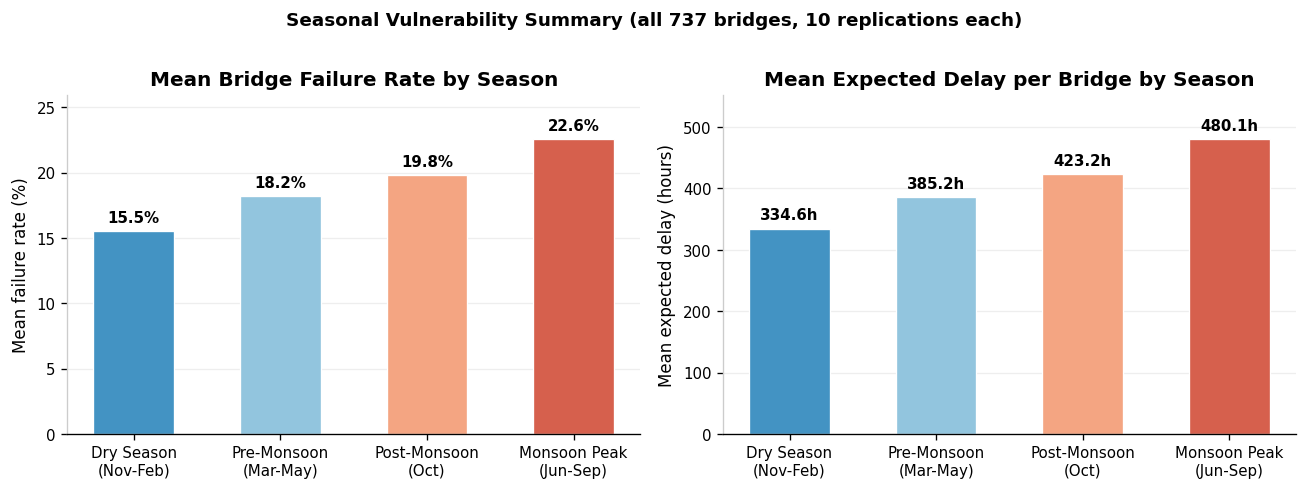

In [2]:
season_summary = (
    vuln_all.groupby('scenario').agg(
        mean_failure_rate  = ('failure_rate',  'mean'),
        mean_expected_delay= ('expected_delay', 'mean'),
    ).reindex(SCENARIO_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig.suptitle('Seasonal Vulnerability Summary (all 737 bridges, 10 replications each)',
             fontsize=11, fontweight='bold', y=1.01)

for ax, col, ylabel, title in zip(
    axes,
    ['mean_failure_rate', 'mean_expected_delay'],
    ['Mean failure rate (%)', 'Mean expected delay (hours)'],
    ['Mean Bridge Failure Rate by Season', 'Mean Expected Delay per Bridge by Season'],
):
    vals = season_summary[col].values * (100 if 'rate' in col else 1/60)
    bars = ax.bar(SCENARIO_LABELS, vals, color=SEASON_COLS,
                  width=0.55, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f'{v:.1f}' + ('%' if 'rate' in col else 'h'),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.spines['left'].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_seasonal_overview.png'))
plt.show()

## 2. Criticality-Vulnerability Priority Matrix

Round 2 criticality has **five discrete tiers** (bridges severing 154, 130, 90, 34, or 0 OD pairs). A normalised scatter collapses these into indistinct horizontal bands. This plot uses a **tiered strip layout** instead:

- **Y-axis**  --  the five criticality tiers, labelled with broken-pair count and % of network cut (top = most critical)
- **X-axis**  --  expected delay in hours (monsoon peak), log-scaled to spread the distribution
- Each dot is one bridge, jittered vertically within its tier for readability
- **Horizontal dotted line**  --  criticality threshold: bridges with any broken pairs (bp >= 34) vs. non-critical (bp = 0)
- **Vertical dashed line**  --  vulnerability threshold: median expected delay across all bridges
- Colour encodes quadrant (A-D), consistent throughout the notebook

| Quadrant | Criticality | Vulnerability | Policy |
|---|---|---|---|
| **A**  --  red | bp >= 34 (Tiers 1-4) | Above median | **Urgent investment** |
| **B**  --  blue | bp >= 34 (Tiers 1-4) | Below median | Preventive monitoring |
| **C**  --  orange | bp = 0 (Tier 5) | Above median | Targeted maintenance |
| **D**  --  grey | bp = 0 (Tier 5) | Below median | Routine maintenance |

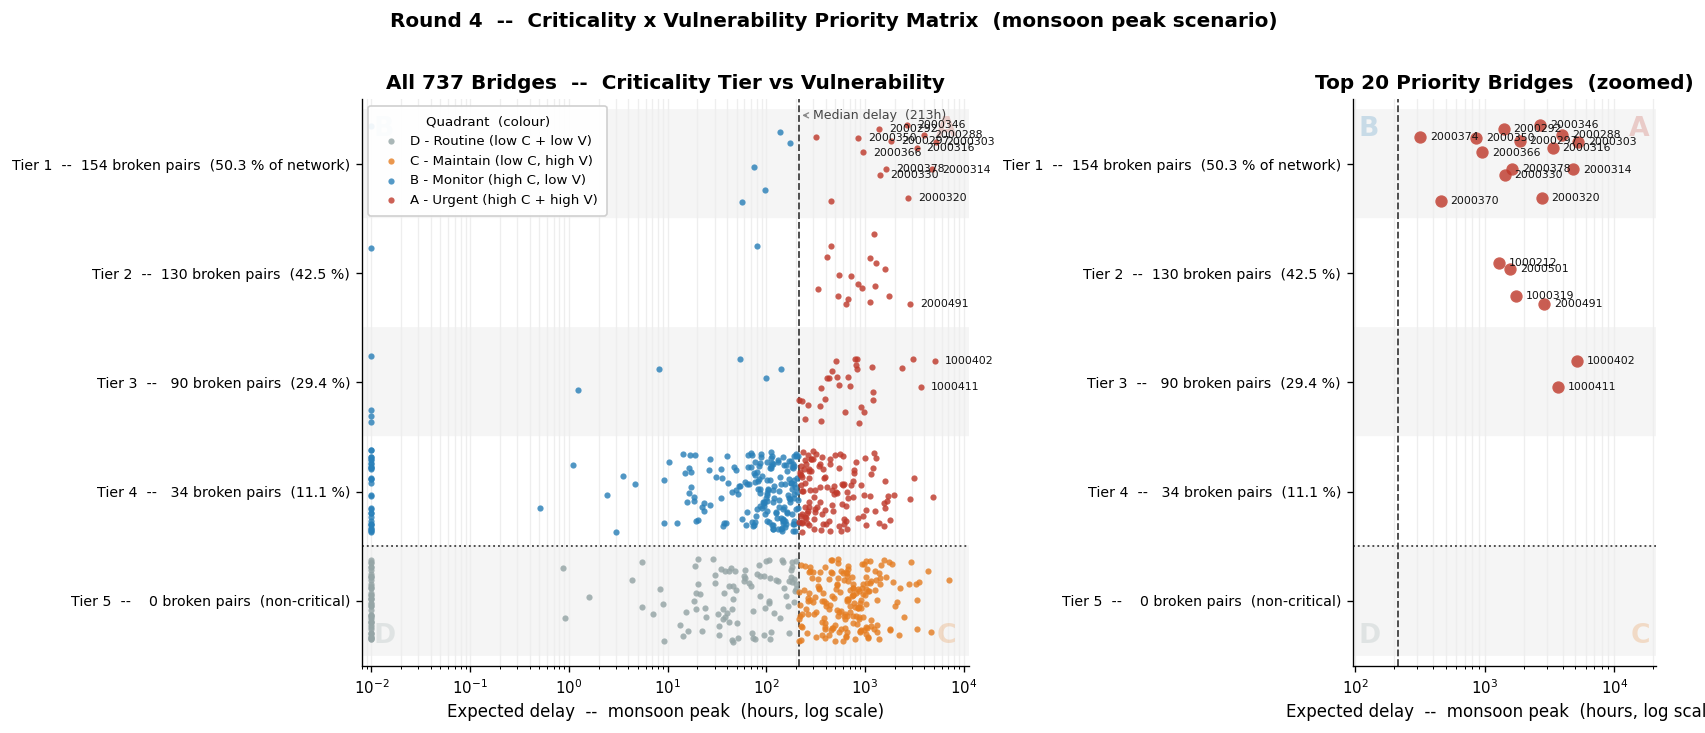

Vulnerability threshold (median): 213.5 hours

Quadrant counts:
  A: 182 bridges  --  A - Urgent (high C + high V)
  B: 227 bridges  --  B - Monitor (high C, low V)
  C: 187 bridges  --  C - Maintain (low C, high V)
  D: 141 bridges  --  D - Routine (low C + low V)


In [3]:
rng = np.random.default_rng(42)

# -- Tier definitions ------------------------------------------
TIER_BP     = [154, 130, 90, 34, 0]
TIER_POS    = [4,   3,   2,  1,  0]   # y-positions; top = most critical
TIER_LABELS = [
    'Tier 1  --  154 broken pairs  (50.3 % of network)',
    'Tier 2  --  130 broken pairs  (42.5 %)',
    'Tier 3  --   90 broken pairs  (29.4 %)',
    'Tier 4  --   34 broken pairs  (11.1 %)',
    'Tier 5  --    0 broken pairs  (non-critical)',
]
bp_to_pos = dict(zip(TIER_BP, TIER_POS))

# -- Prepare data ----------------------------------------------
p = priority.copy()
p['tier_y']  = p['broken_pairs'].map(bp_to_pos)
p['jitter']  = rng.uniform(-0.38, 0.38, size=len(p))
p['y_plot']  = p['tier_y'] + p['jitter']
p['delay_h'] = (p['expected_delay'] / 60).clip(lower=0.01)  # hours; floor for log scale

# Thresholds  --  consistent with priority_matrix.csv quadrant assignment
v_thresh_h = p['delay_h'].median()   # median expected delay (hours)
c_thresh_y  = 0.5                    # between bp=0 (pos=0) and bp=34 (pos=1)

# -- Two-panel figure ---------------------------------------------
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                               gridspec_kw={'width_ratios': [2, 1]})

def _draw_strip(ax, data, dot_size, label_df=None, xlim=None, show_legend=False):
    """Shared drawing logic for both panels.
    label_df: a DataFrame whose rows will be annotated with bridge_id.
    """
    # Alternating tier band backgrounds
    for pos in TIER_POS:
        ax.axhspan(pos - 0.5, pos + 0.5,
                   color='#f5f5f5' if pos % 2 == 0 else 'white', zorder=0)

    # Threshold lines
    ax.axvline(v_thresh_h, color='#444444', linestyle='--',
               linewidth=1.1, zorder=2)
    ax.axhline(c_thresh_y, color='#444444', linestyle=':',
               linewidth=1.1, zorder=2)

    # Background grey layer (all bridges in this panel)
    ax.scatter(data['delay_h'], data['y_plot'],
               c='#d0d0d0', s=dot_size * 0.6, alpha=0.35,
               zorder=1, linewidths=0)

    # Coloured quadrant layer  --  draw A last so red sits on top
    for quad in ['D', 'C', 'B', 'A']:
        grp = data[data['quadrant'] == quad]
        ax.scatter(grp['delay_h'], grp['y_plot'],
                   c=QCOL[quad], s=dot_size, alpha=0.80,
                   zorder=3, linewidths=0,
                   label=QLABEL[quad] if show_legend else None)

    # Bridge-ID annotations (only if a label DataFrame is provided)
    if label_df is not None:
        for _, row in label_df.iterrows():
            ax.annotate(
                str(int(row['bridge_id'])),
                xy=(row['delay_h'], row['y_plot']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=6.5, color='#111111', va='center', zorder=5,
            )

    # Faint quadrant corner badges
    for txt, xf, yf in [('A', 0.98, 0.97), ('B', 0.02, 0.97),
                         ('C', 0.98, 0.03), ('D', 0.02, 0.03)]:
        ax.text(xf, yf, txt, transform=ax.transAxes,
                fontsize=16, fontweight='bold', color=QCOL[txt], alpha=0.22,
                ha='right' if xf > 0.5 else 'left',
                va='top'   if yf > 0.5 else 'bottom')

    ax.set_xscale('log')
    ax.set_xlim(xlim if xlim is not None else (0.008, data['delay_h'].max() * 1.6))
    ax.set_ylim(-0.6, 4.6)
    ax.set_yticks(TIER_POS)
    ax.set_yticklabels(TIER_LABELS, fontsize=8.5)
    ax.set_xlabel('Expected delay  --  monsoon peak  (hours, log scale)')
    ax.xaxis.grid(True, which='both', color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)


# -- Left panel: all 737 bridges -------------------------------
_draw_strip(ax, p, dot_size=14,
            label_df=p.nsmallest(15, 'priority_rank'),
            show_legend=True)
ax.set_title('All 737 Bridges  --  Criticality Tier vs Vulnerability')

# Annotate threshold lines
ax.annotate(f'Median delay  ({v_thresh_h:.0f}h)',
            xy=(v_thresh_h, 4.45), xytext=(v_thresh_h * 1.4, 4.45),
            fontsize=7.5, color='#444444', va='center',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=0.8))

ax.legend(loc='upper left', fontsize=8, framealpha=0.92,
          handletextpad=0.4, borderpad=0.7,
          title='Quadrant  (colour)', title_fontsize=8)

# -- Right panel: top 20 only (zoomed) -------------------------
top20p = p.nsmallest(20, 'priority_rank').copy()
_draw_strip(ax2, top20p, dot_size=55,
            label_df=top20p,
            xlim=(top20p['delay_h'].min() * 0.3, top20p['delay_h'].max() * 4))
ax2.set_title('Top 20 Priority Bridges  (zoomed)')

fig.suptitle('Round 4  --  Criticality x Vulnerability Priority Matrix  '
             '(monsoon peak scenario)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_priority_matrix.png'))
plt.show()

print(f'Vulnerability threshold (median): {v_thresh_h:.1f} hours')
print(f'\nQuadrant counts:')
for q in 'ABCD':
    n = (priority['quadrant'] == q).sum()
    print(f'  {q}: {n} bridges  --  {QLABEL[q]}')

## 3. Top 20 Priority Bridges  --  Decomposed Score

Each bar is split into its **criticality contribution** (blue, `0.5 x norm_criticality`) and **vulnerability contribution** (red, `0.5 x norm_vulnerability`). This shows not just rank but *why* each bridge ranks where it does.

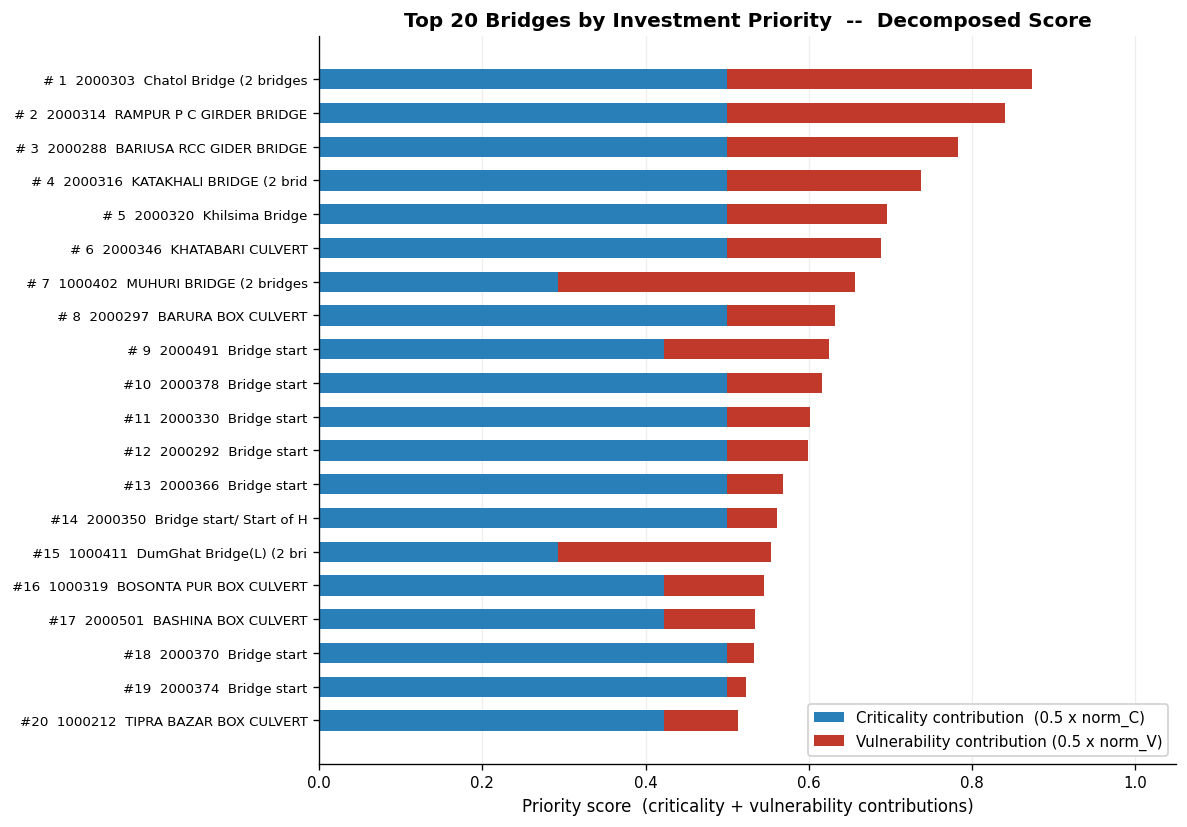

In [4]:
top20 = priority.head(20).copy()
top20['c_contrib'] = 0.5 * top20['norm_criticality']
top20['v_contrib'] = 0.5 * top20['norm_vulnerability']
top20['label'] = top20.apply(
    lambda r: f"{int(r['bridge_id'])}  {r['name'][:22]}", axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(top20))

# Plot in reverse order so rank 1 is at the top
ax.barh(y, top20['c_contrib'][::-1].values,
        color=COL_CRIT, label='Criticality contribution  (0.5 x norm_C)', height=0.6)
ax.barh(y, top20['v_contrib'][::-1].values,
        left=top20['c_contrib'][::-1].values,
        color=COL_VULN, label='Vulnerability contribution (0.5 x norm_V)', height=0.6)

ax.set_yticks(y)
ax.set_yticklabels(
    [f"#{int(r['priority_rank']):2d}  {int(r['bridge_id'])}  {r['name'][:24]}"
     for _, r in list(top20.iterrows())[::-1]],
    fontsize=8
)
ax.set_xlabel('Priority score  (criticality + vulnerability contributions)')
ax.set_title('Top 20 Bridges by Investment Priority  --  Decomposed Score')
ax.set_xlim(0, 1.05)
ax.xaxis.grid(True, color='#eeeeee', zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_top20_decomposed.png'))
plt.show()

## 4. Sensitivity Analysis  --  Rank Stability

A heatmap showing the rank of each top-20 bridge under three weight configurations. Darker cells = higher rank (more critical). Bridges whose rank changes little across columns are the most robust priorities.

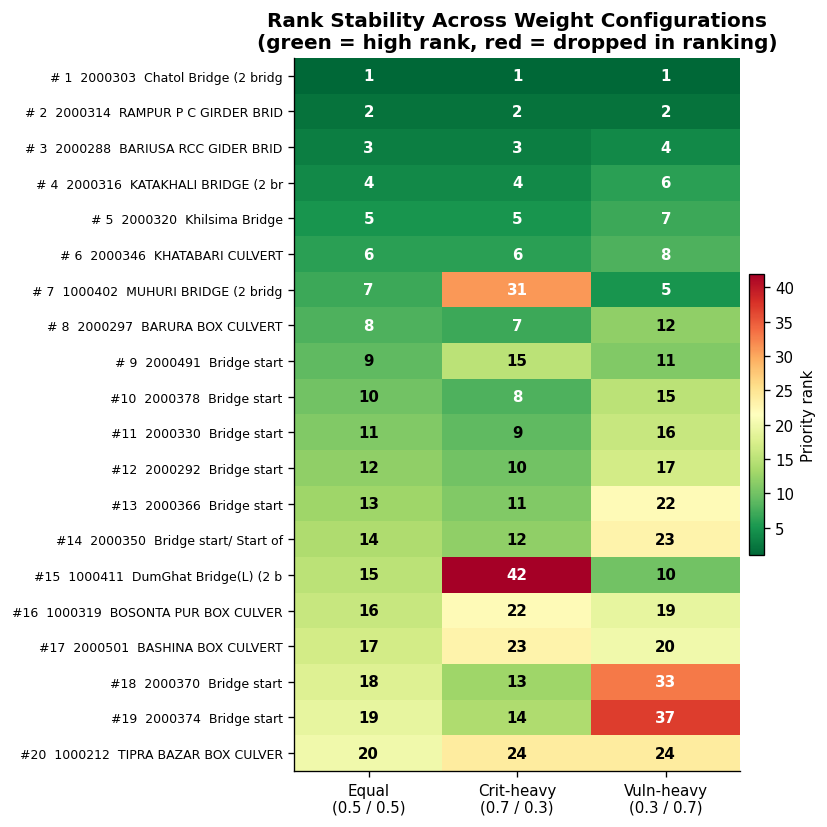

Bridges in top 20 under ALL three configurations: 11
[2000288, 2000292, 2000297, 2000303, 2000314, 2000316, 2000320, 2000330, 2000346, 2000378, 2000491]


In [5]:
CONFIGS = {
    'Equal\n(0.5 / 0.5)':      'priority_equal',
    'Crit-heavy\n(0.7 / 0.3)': 'priority_crit_heavy',
    'Vuln-heavy\n(0.3 / 0.7)': 'priority_vuln_heavy',
}

default_top20 = priority.head(20)['bridge_id'].tolist()

# Build rank matrix: rows = default-top-20 bridges, cols = configurations
rank_matrix = pd.DataFrame(index=default_top20, columns=list(CONFIGS.keys()))
for col_label, score_col in CONFIGS.items():
    ranked = priority.sort_values(score_col, ascending=False).reset_index(drop=True)
    ranked['_rank'] = ranked.index + 1
    lookup = ranked.set_index('bridge_id')['_rank']
    for bid in default_top20:
        rank_matrix.loc[bid, col_label] = int(lookup[bid])
rank_matrix = rank_matrix.astype(int)

# Row labels
row_labels = [
    f"#{priority[priority['bridge_id']==bid]['priority_rank'].values[0]:2d}  "
    f"{bid}  {priority[priority['bridge_id']==bid]['name'].values[0][:22]}"
    for bid in default_top20
]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(rank_matrix.values, aspect='auto', cmap='RdYlGn_r',
               vmin=1, vmax=max(40, int(rank_matrix.values.max())))

# Cell annotations
for r in range(len(default_top20)):
    for c in range(len(CONFIGS)):
        v = rank_matrix.values[r, c]
        txt_color = 'white' if v <= 8 or v >= 30 else 'black'
        ax.text(c, r, str(v), ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

ax.set_xticks(range(len(CONFIGS)))
ax.set_xticklabels(list(CONFIGS.keys()), fontsize=9)
ax.set_yticks(range(len(default_top20)))
ax.set_yticklabels(row_labels, fontsize=7.5)
ax.set_title('Rank Stability Across Weight Configurations\n'
             '(green = high rank, red = dropped in ranking)')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Priority rank', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_sensitivity_heatmap.png'))
plt.show()

# Summary
stable = set(default_top20)
for col in rank_matrix.columns:
    stable &= set(rank_matrix[rank_matrix[col] <= 20].index.tolist())
print(f'Bridges in top 20 under ALL three configurations: {len(stable)}')
print(sorted(stable))

## 5. Seasonal Delay Heatmap  --  Top 15 Priority Bridges

Expected delay (hours) for the top 15 bridges across all four seasonal scenarios. The monsoon premium (right column vs left column) reveals which bridges are driven by chronic structural weakness vs seasonal flood exposure.

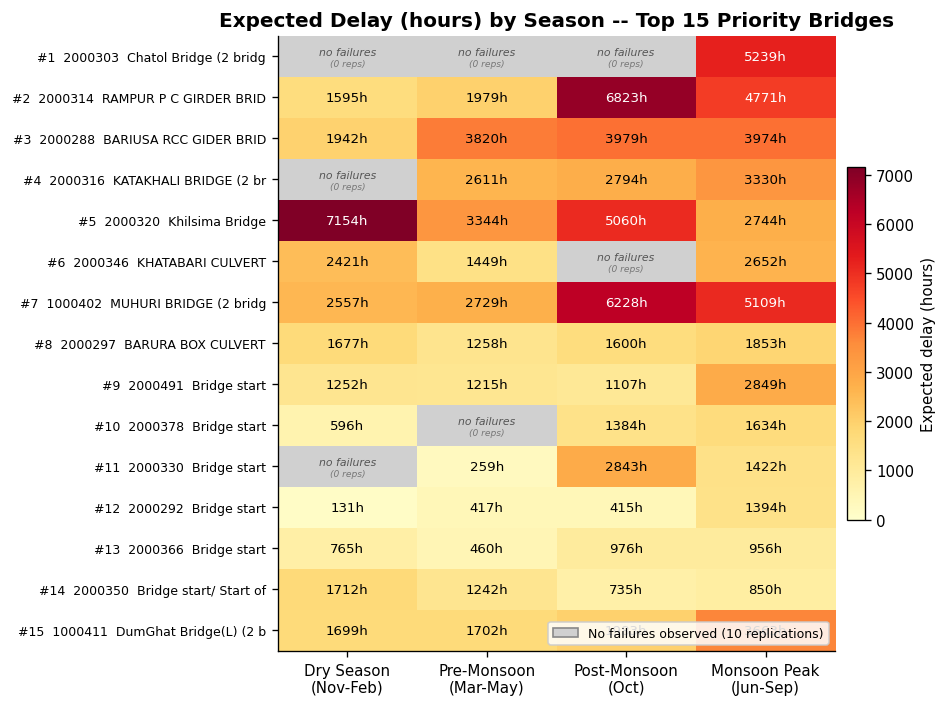

In [6]:

top15_ids   = priority.head(15)['bridge_id'].tolist()
top15_names = priority.head(15).set_index('bridge_id')['name'].to_dict()

seasonal_pivot = (
    vuln_all[vuln_all['bridge_id'].isin(top15_ids)]
    .pivot(index='bridge_id', columns='scenario', values='expected_delay')
    [SCENARIO_ORDER]
    / 60  # convert to hours
)
seasonal_pivot = seasonal_pivot.reindex(top15_ids)  # preserve priority order

# Boolean mask: True where expected_delay == 0 (no failures in 10 reps)
zero_mask = seasonal_pivot.values == 0

# For the colour scale, treat zeros as NaN so they render as a distinct colour
plot_vals = seasonal_pivot.values.astype(float)
plot_vals[zero_mask] = np.nan

row_labels = [
    f"#{priority[priority['bridge_id']==bid]['priority_rank'].values[0]}  "
    f"{bid}  {top15_names[bid][:22]}"
    for bid in top15_ids
]

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#d0d0d0')  # grey for masked (zero) cells

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(plot_vals, aspect='auto', cmap=cmap, vmin=0)

# Cell annotations
vmax = np.nanmax(plot_vals)
for r in range(len(top15_ids)):
    for c in range(4):
        v = seasonal_pivot.values[r, c]
        if v == 0:
            ax.text(c, r - 0.12, 'no failures', ha='center', va='center',
                    fontsize=6.5, color='#555555', style='italic')
            ax.text(c, r + 0.18, '(0 reps)', ha='center', va='center',
                    fontsize=5.5, color='#777777', style='italic')
        else:
            txt_color = 'white' if v > vmax * 0.65 else 'black'
            ax.text(c, r, f'{v:.0f}h', ha='center', va='center',
                    fontsize=8, color=txt_color)

ax.set_xticks(range(4))
ax.set_xticklabels(SCENARIO_LABELS, fontsize=9)
ax.set_yticks(range(len(top15_ids)))
ax.set_yticklabels(row_labels, fontsize=7.5)
ax.set_title('Expected Delay (hours) by Season -- Top 15 Priority Bridges')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Expected delay (hours)', fontsize=9)

# Legend patch explaining grey cells
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor='#d0d0d0', edgecolor='#888888',
                   label='No failures observed (10 replications)')],
    loc='lower right', fontsize=7.5, framealpha=0.85
)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_seasonal_delay_heatmap.png'))
plt.show()

## 6. Final Investment Recommendation  --  Quadrant A Bridges

Quadrant A bridges score **above the median on both dimensions**. These are the primary candidates for World Bank investment.

In [7]:
quad_a = priority[priority['quadrant'] == 'A'].sort_values('priority_equal', ascending=False)

display_cols = [
    'priority_rank', 'bridge_id', 'name', 'road',
    'broken_pairs', 'broken_pct',
    'failure_rate', 'expected_delay',
    'norm_criticality', 'norm_vulnerability', 'priority_equal',
]
out = quad_a.head(20)[display_cols].copy()
out['failure_rate']    = (out['failure_rate'] * 100).round(1)
out['expected_delay']  = out['expected_delay'].apply(lambda x: f'{x/60:,.1f}h')
out['norm_criticality']  = out['norm_criticality'].round(3)
out['norm_vulnerability']= out['norm_vulnerability'].round(3)
out['priority_equal']  = out['priority_equal'].round(3)
out.columns = [
    'R4 rank', 'Bridge ID', 'Name', 'Road',
    'Broken pairs', 'Broken %',
    'Fail rate %', 'Exp. delay',
    'norm C', 'norm V', 'Priority',
]
print(f'Total Quadrant A bridges: {len(quad_a)}')
print(f'\nTop 20 Quadrant A bridges:\n')
print(out.to_string(index=False))

Total Quadrant A bridges: 182

Top 20 Quadrant A bridges:

 R4 rank  Bridge ID                                                                                          Name Road  Broken pairs  Broken %  Fail rate % Exp. delay  norm C  norm V  Priority
       1    2000303                                                         Chatol Bridge (2 bridges at crossing)   N2           154     50.33         40.0   5,239.2h   1.000   0.746     0.873
       2    2000314                                              RAMPUR P C GIRDER BRIDGE (2 bridges at crossing)   N2           154     50.33         30.0   4,770.9h   1.000   0.680     0.840
       3    2000288                                              BARIUSA RCC GIDER BRIDGE (2 bridges at crossing)   N2           154     50.33         40.0   3,974.0h   1.000   0.566     0.783
       4    2000316                                                      KATAKHALI BRIDGE (2 bridges at crossing)   N2           154     50.33         40.0   3,330.1h   

## 7. Cross-Round Summary

Links all four rounds for the top 20 priority bridges. `R1 rank` = Round 1 combined score rank; `R2 rank` = Round 2 criticality rank; `R3 rate` and `R3 delay` = Round 3 monsoon peak outputs; `R4 rank` = final priority.

In [8]:
r1 = pd.read_csv('../experiment/round1_baseline/bridge_ranking.csv',
                 usecols=['bridge_id', 'rank_by_combined'])
r1.columns = ['bridge_id', 'r1_rank']

cross = (
    priority.head(20)[[
        'priority_rank', 'bridge_id', 'name', 'road',
        'criticality_rank', 'broken_pairs',
        'failure_rate', 'expected_delay', 'quadrant', 'priority_equal',
    ]]
    .merge(r1, on='bridge_id', how='left')
)
cross['failure_rate']   = (cross['failure_rate'] * 100).round(1)
cross['expected_delay'] = cross['expected_delay'].apply(lambda x: f'{x/60:,.1f}h')
cross['r1_rank']        = cross['r1_rank'].fillna(' -- ').astype(str).str.replace('.0','',regex=False)
cross['priority_equal'] = cross['priority_equal'].round(3)

cross.columns = [
    'R4 rank', 'Bridge ID', 'Name', 'Road',
    'R2 rank', 'Broken pairs',
    'R3 fail %', 'R3 exp. delay', 'Quadrant', 'R4 score', 'R1 rank',
]
# Reorder columns so round sequence reads left to right
cross = cross[[
    'R1 rank', 'R2 rank', 'Broken pairs',
    'R3 fail %', 'R3 exp. delay',
    'R4 rank', 'R4 score', 'Quadrant',
    'Bridge ID', 'Name', 'Road',
]]
print('Cross-round summary  --  top 20 by Round 4 priority score:')
print(cross.to_string(index=False))

Cross-round summary  --  top 20 by Round 4 priority score:
R1 rank  R2 rank  Broken pairs  R3 fail % R3 exp. delay  R4 rank  R4 score Quadrant  Bridge ID                                                                                          Name Road
      6        7           154       40.0      5,239.2h        1     0.873        A    2000303                                                         Chatol Bridge (2 bridges at crossing)   N2
      8        9           154       30.0      4,770.9h        2     0.840        A    2000314                                              RAMPUR P C GIRDER BRIDGE (2 bridges at crossing)   N2
      3        4           154       40.0      3,974.0h        3     0.783        A    2000288                                              BARIUSA RCC GIDER BRIDGE (2 bridges at crossing)   N2
      9       10           154       40.0      3,330.1h        4     0.737        A    2000316                                                      KATAKHALI BRIDGE 